# Lab 5 - Logistic Regression and Support Vector Machine
The goal of this lab is to deepen you understanding of using logistic regression and SVM for classification tasks.

In [2]:
!pip install idx2numpy

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import idx2numpy

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, precision_score, accuracy_score
from torchvision import datasets, transforms
from collections import Counter

## Task 1: Predict Breast Cancer using Logistic Regression 

In [3]:
df = pd.read_csv("breast_cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df = df.drop('Unnamed: 32', axis=1)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df = df.dropna()
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


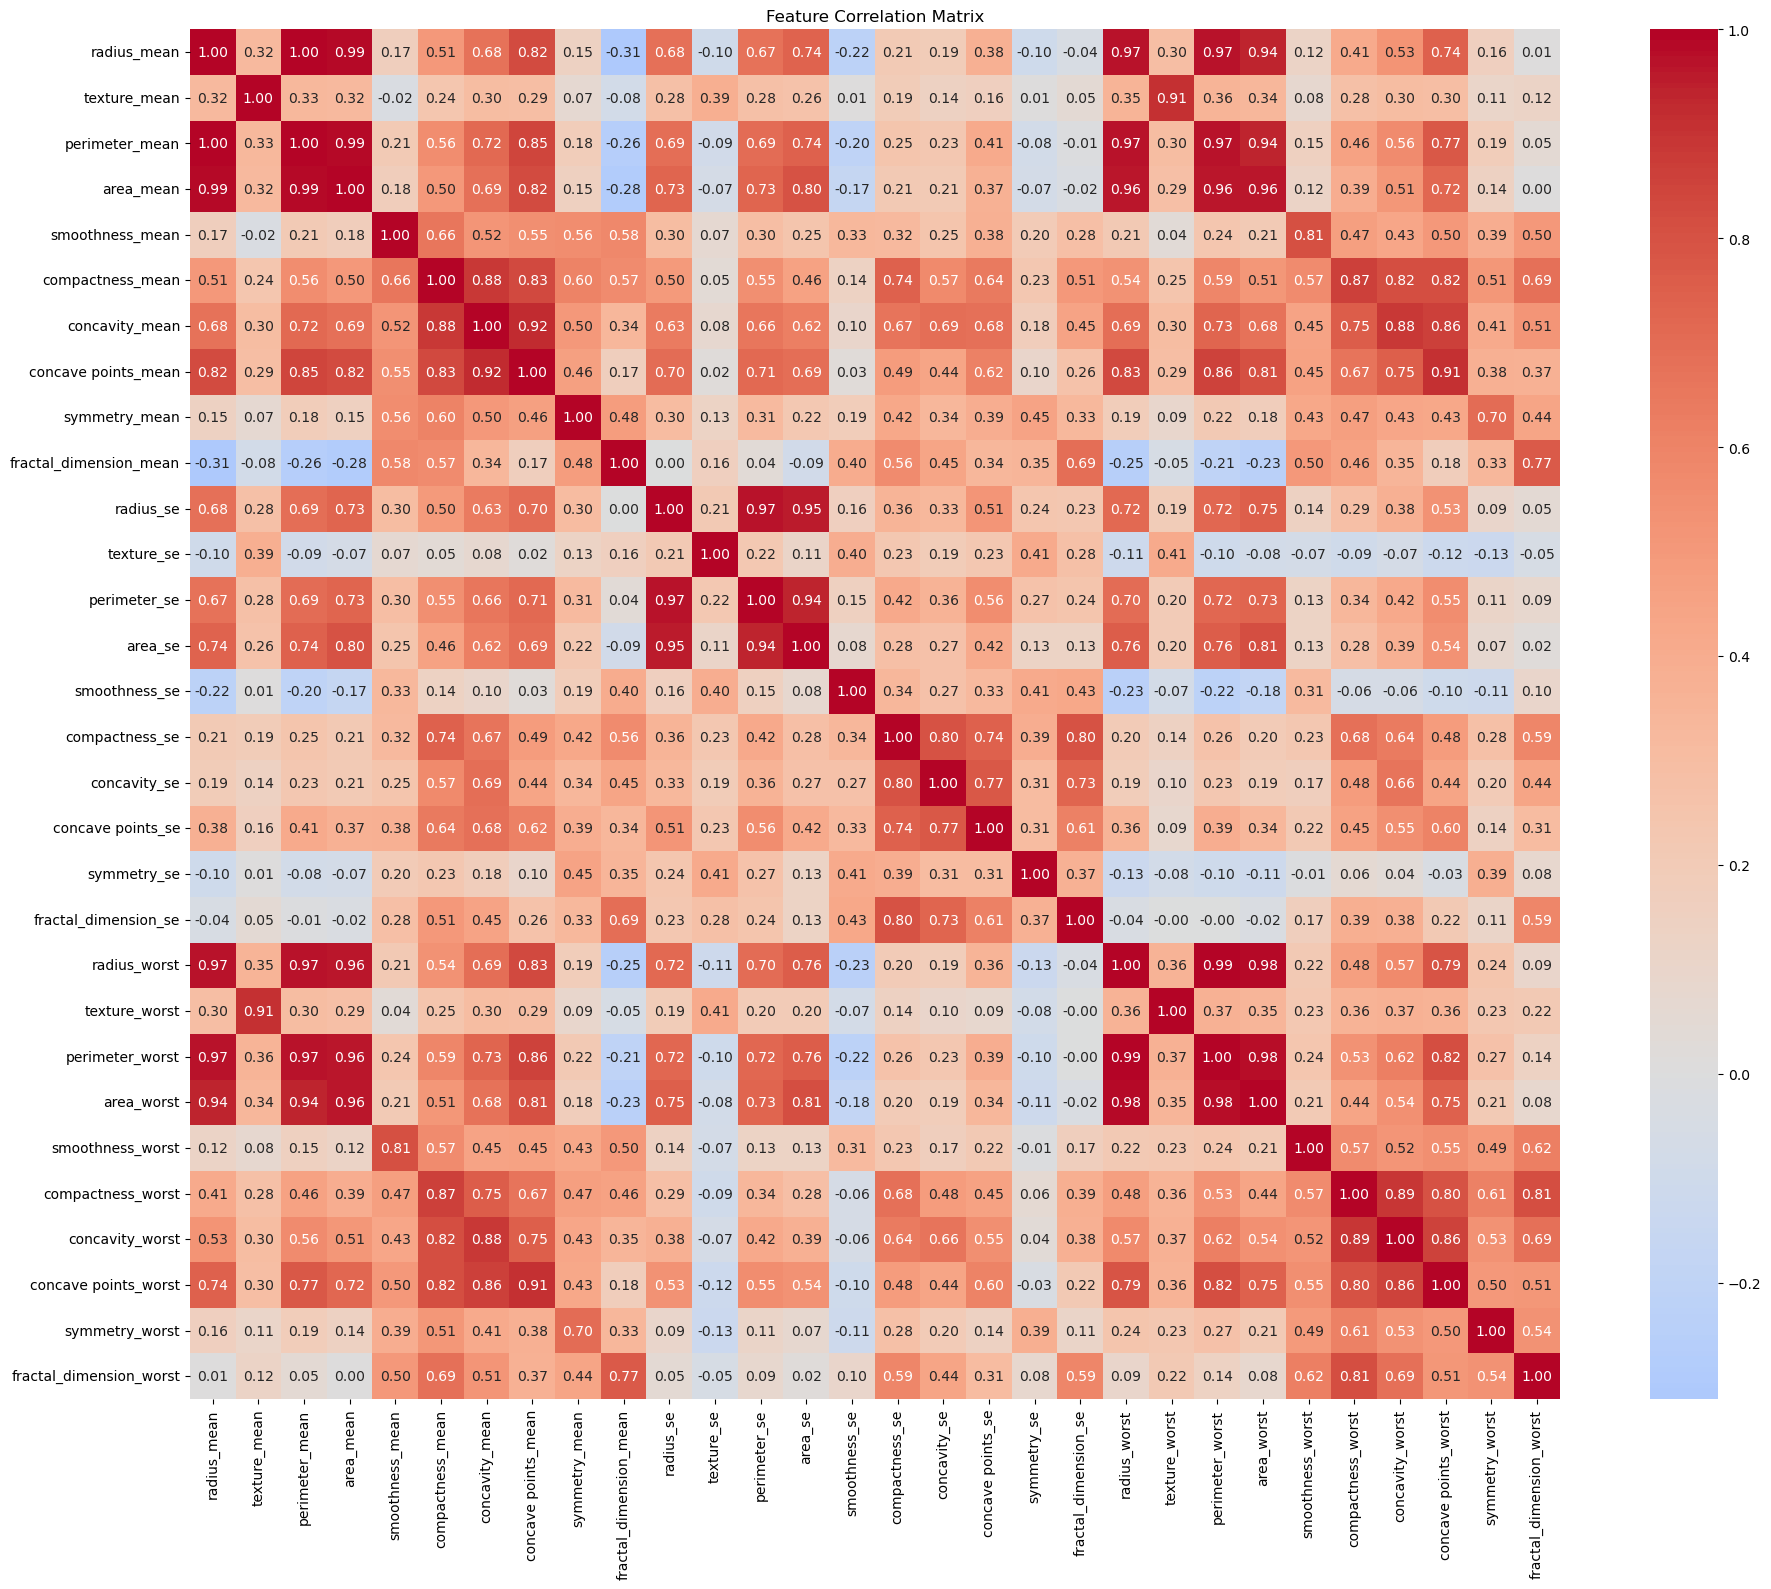

In [6]:
# Select only numeric feature columns (exclude target)
features = df.drop(columns=['diagnosis'])

# Correlation heatmap
plt.figure(figsize=(20, 16))
corr_matrix = features.corr()
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [7]:
# Features to drop based on correlation analysis (|r| > 0.90)
to_drop = [
    # Size group - perimeter and area are derived from radius
    'perimeter_mean', 'area_mean',
    'perimeter_se', 'area_se',
    'perimeter_worst', 'area_worst',
    
    # Mean vs Worst redundancy
    'radius_worst', 'concavity_worst', 'concave points_worst',
    
    # Compactness/Concavity shape cluster
    'concavity_mean',
]

df_model = df.drop(columns=to_drop)
features = df_model.drop(columns=['diagnosis'])

print(f"Dropped {len(to_drop)} features: {to_drop}")
print(f"Remaining: {features.shape[1]} features")

Dropped 10 features: ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'perimeter_worst', 'area_worst', 'radius_worst', 'concavity_worst', 'concave points_worst', 'concavity_mean']
Remaining: 20 features


### Explanation
Ten features were removed due to redundancy (|r| > 0.90). Perimeter and area - in their mean, SE, and worst forms - were dropped because they are geometrically derived from radius and carry no independent information. radius_worst, concavity_worst, and concave_points_worst were dropped as their _mean counterparts capture the same signal. Finally, concavity_mean was dropped in favor of concave_points_mean, which is a more direct and interpretable measure of tumor shape irregularity. The remaining 20 features represent independent, non-redundant signals for logistic regression.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    features, df_model['diagnosis'], test_size=0.2, random_state=42, stratify=df_model['diagnosis'])

# Create and fit the Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Predictions on the testing set
y_pred = model.predict(X_test)

In [9]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

Precision: 0.9487
Accuracy: 0.9386
F1 Score: 0.9381


### Model Performance Discussion

The model performs well overall with 93.9% accuracy and a f1 score of 93.8%. The weakness of the model appear in the metrics for malignant cases prediction, with a recall score of 88%. This means that the model misses 12% of actual cancer cases (false negatives). In a clinical context this is the critical weakness as failing to flag a malignant tumor is more costly than a false positive. However, the precision for malignant is 95% which is good since when it predicts malignant it is usually corrrect.

## Task 2: Digit Recognition using SVM 

In [ ]:
# your code goes below

In [10]:
# Define the transformation to convert images to PyTorch tensors
transform = transforms.Compose([transforms.ToTensor()])

# Load the MNIST dataset with the specified transformation
mnist_pytorch = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# Create a DataLoader to load the dataset in batches
train_loader_pytorch = torch.utils.data.DataLoader(mnist_pytorch, batch_size=1, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



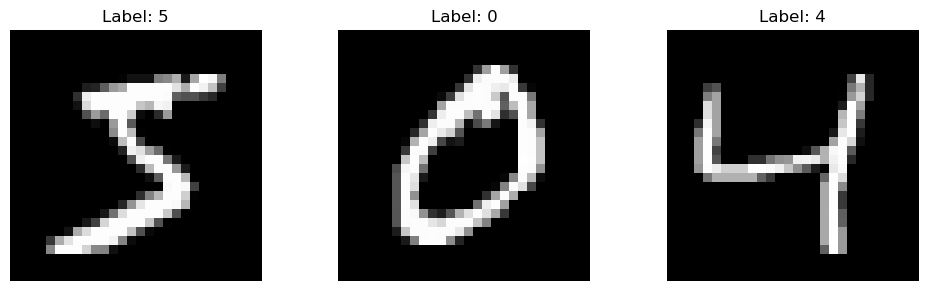

In [11]:
# Plot the first three images
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for idx, (image, label) in enumerate(train_loader_pytorch):
    if idx == 3:  # Stop after displaying the first three images
        break
    axes[idx].imshow(image.squeeze().numpy(), cmap='gray')
    axes[idx].set_title(f'Label: {label.item()}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Load MNIST dataset. Path subject to change
X_train = './data/MNIST/raw/train-images-idx3-ubyte'
y_train = './data/MNIST/raw/train-labels-idx1-ubyte'
X_test = './data/MNIST/raw/t10k-images-idx3-ubyte'
y_test = './data/MNIST/raw/t10k-labels-idx1-ubyte'

X_train = idx2numpy.convert_from_file(X_train)
y_train = idx2numpy.convert_from_file(y_train)
X_test = idx2numpy.convert_from_file(X_test)
y_test = idx2numpy.convert_from_file(y_test)

# Vectorization the images
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

# Normalize the data
X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.shape)

(60000, 784)


In [12]:
linear_model = SVC(kernel='linear')
# Fit SVM
linear_model.fit(X_train, y_train)

# Prediction using SVM
y_pred = linear_model.predict(X_test)

In [13]:
# Evaluation metrics
# Linear SVM
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        72
           1       0.95      0.83      0.89        42

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114



In [14]:
non_linear_model = SVC(kernel='rbf') # Alternative choice: kernel='poly'
# Fit SVM
non_linear_model.fit(X_train, y_train)

# Prediction using SVM
y_pred = non_linear_model.predict(X_test)

In [15]:
# Evaluation metrics
# Non-linear SVM
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        72
           1       0.94      0.76      0.84        42

    accuracy                           0.89       114
   macro avg       0.91      0.87      0.88       114
weighted avg       0.90      0.89      0.89       114



### Comparison

Non linear SVM outperforms the linear kernel because MNIST digit classification is inherently non-linear - pixel intensities don't separate cleanly in a linear feature space. The non linear kernel implicitly maps data into a higher-dimensional space where class boundaries become separable, capturing the complex spatial relationships between pixels that a linear hyperplane cannot. For image classification tasks like MNIST, non-linear kernels are almost always superior.

## Task 3: k-Nearest Neighbor Algorithm for Breast Cancer Prediction 

Best k: 11 with CV accuracy: 0.9604


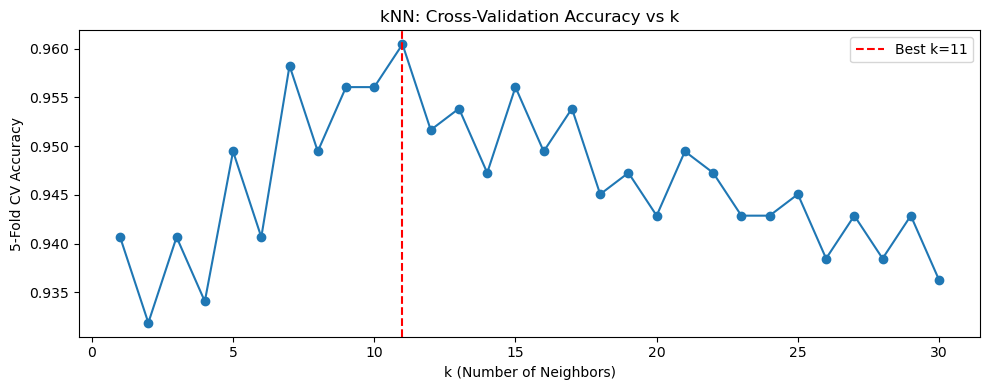

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

X = df_model.drop(columns=['diagnosis'])
y = df_model['diagnosis']

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bc)
X_test_scaled = scaler.transform(X_test_bc)

k_range = range(1, 31)
cv_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train_bc, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f"Best k: {best_k} with CV accuracy: {max(cv_scores):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(k_range, cv_scores, marker='o')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('5-Fold CV Accuracy')
plt.title('kNN: Cross-Validation Accuracy vs k')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train_bc)
y_pred_knn = knn_final.predict(X_test_scaled)

print(f"kNN (k={best_k}) Classification Report:")
print(classification_report(y_test_bc, y_pred_knn))
print(f"Precision: {precision_score(y_test_bc, y_pred_knn):.4f}")
print(f"Accuracy:  {accuracy_score(y_test_bc, y_pred_knn):.4f}")
print(f"F1 Score:  {classification_report(y_test_bc, y_pred_knn, output_dict=True)['weighted avg']['f1-score']:.4f}")

kNN (k=11) Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        72
           1       0.95      0.86      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114

Precision: 0.9474
Accuracy:  0.9298
F1 Score:  0.9290


### Model Performance Discussion

The kNN classifier with the optimal k (selected via 5-fold cross-validation) achieves competitive performance on the breast cancer dataset. Feature scaling with StandardScaler is critical here because kNN relies on Euclidean distance - without it, features with larger numeric ranges would dominate the distance calculation and bias predictions.

Compared to Logistic Regression from Task 1:
- kNN is a non-parametric, instance-based learner that makes no assumptions about the decision boundary shape, giving it flexibility on small datasets like this one.
- Logistic Regression is faster to train and produces probabilistic outputs useful for threshold tuning, which is valuable in clinical settings.
- kNN's main drawback is its sensitivity to irrelevant features and its O(n) prediction cost — both manageable here given the small dataset and the feature selection already performed.

Overall, both models perform similarly on this dataset (~94% accuracy), but Logistic Regression is preferred in clinical practice due to its interpretability and calibrated probability estimates for malignancy risk.